In [ ]:
# Drive mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [ ]:
# matplotlibで日本語を使うための対応モジュール
!pip install japanize-matplotlib
import japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 21.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=a0350f2d123e15c9920b0ee1e03c226186fd308aa4413f9d042461174c94c55f
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


In [30]:
path = "/content/drive/MyDrive/43_アメダス気象観測/Cleansing_data(2005-2025)/2005_to_2026Jun.csv"
df = pd.read_csv(path)

df["年月日"] = pd.to_datetime(df["年月日"])

df = df.set_index("年月日")

display(df.info())
display(df)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7830 entries, 2005-01-01 to 2026-06-09
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   平均気温(℃)     7830 non-null   float64
 1   最高気温(℃)     7830 non-null   float64
 2   最低気温(℃)     7830 non-null   float64
 3   降水量の合計(mm)  7830 non-null   float64
 4   日照時間(時間)    7830 non-null   float64
 5   平均風速(m/s)   7830 non-null   float64
dtypes: float64(6)
memory usage: 428.2 KB


None

,平均気温(℃),最高気温(℃),最低気温(℃),降水量の合計(mm),日照時間(時間),平均風速(m/s)
年月日,,,,,,
2005-01-01,0.5,7.4,-5.8,0.0,7.4,2.4
2005-01-02,-1.6,8.4,-9.1,0.0,8.2,0.7
2005-01-03,-0.7,7.7,-7.9,0.0,4.3,0.5
2005-01-04,4.7,15.6,-3.9,0.0,8.2,2.7
2005-01-05,1.6,7.4,-4.5,0.0,8.1,2.6
...,...,...,...,...,...,...
2026-06-05,18.7,23.3,14.0,0.0,2.1,1.4
2026-06-06,19.2,25.7,15.5,0.0,4.7,1.1
2026-06-07,18.3,21.7,14.9,7.0,0.0,1.1


In [7]:
# データを年月日で取り出す
start_day = "2024-01-01"
end_date = "2026-06-02"
df_2025 = df.loc[start_day:end_date]

# pd.set_option("display.max_rows", None)
print(df_2025.info())
pd.get_option("display.max_rows")

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 884 entries, 2024-01-01 to 2026-06-02
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   平均気温(℃)     884 non-null    float64
 1   最高気温(℃)     884 non-null    float64
 2   最低気温(℃)     884 non-null    float64
 3   降水量の合計(mm)  884 non-null    float64
 4   日照時間(時間)    884 non-null    float64
 5   平均風速(m/s)   884 non-null    float64
dtypes: float64(6)
memory usage: 48.3 KB
None


60

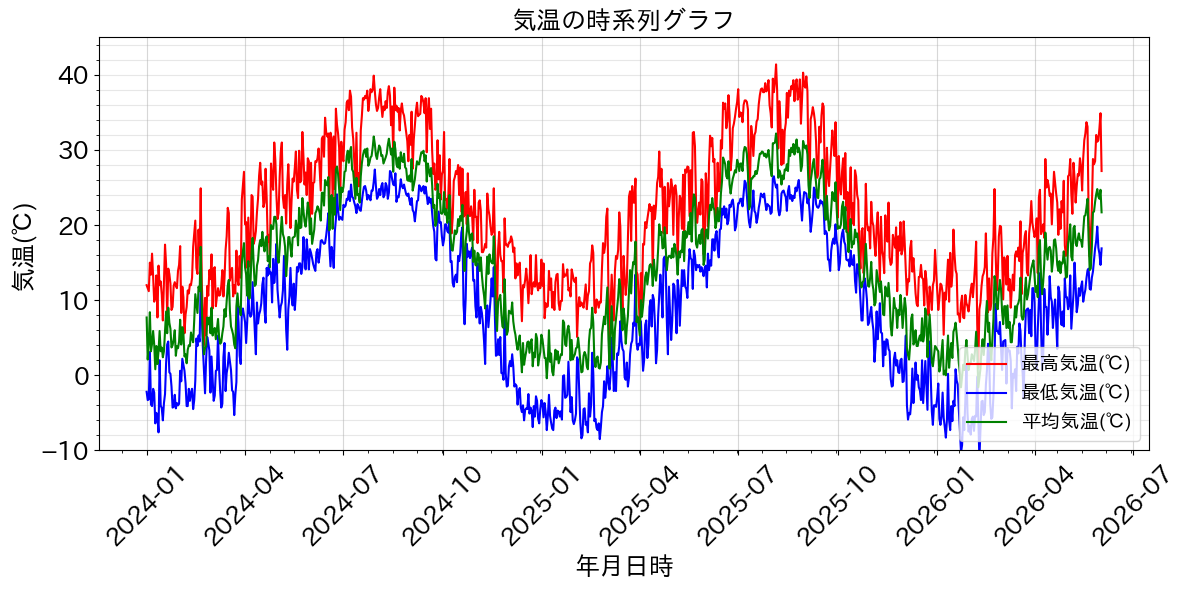

In [8]:
# 気温の時系列グラフ
plt.figure(figsize=(12, 6))
plt.plot(df_2025.index, df_2025["最高気温(℃)"], label="最高気温(℃)", c="red")
plt.plot(df_2025.index, df_2025["最低気温(℃)"], label="最低気温(℃)", c="blue")
plt.plot(df_2025.index, df_2025["平均気温(℃)"], label="平均気温(℃)", c="green")

plt.title("気温の時系列グラフ", fontsize=18)
plt.xlabel("年月日時", fontsize=18)
plt.ylabel("気温(℃)", fontsize=18)

plt.xticks(fontsize=18, rotation=45)
plt.yticks(fontsize=18)

plt.minorticks_on()
plt.grid(True, alpha=0.5)
plt.grid(which="both", axis="y", alpha=0.3)

plt.legend(loc="lower right", fontsize=14)
plt.ylim(-10, 45)

plt.tight_layout()
plt.show()

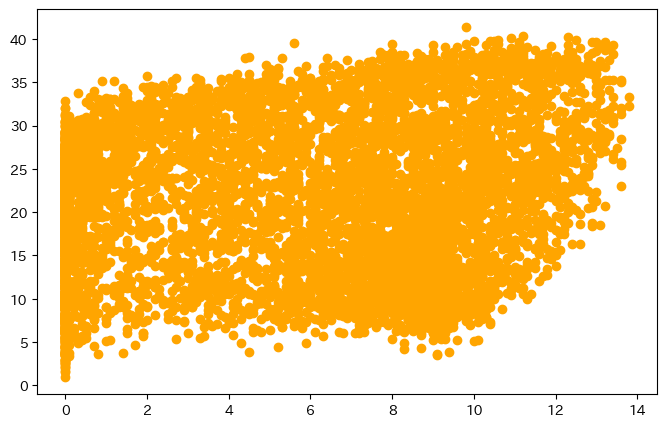

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(df["日照時間(時間)"], df["最高気温(℃)"], color="orange", label="最高気温")



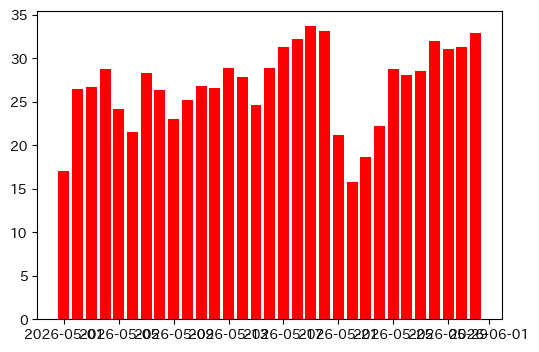

In [18]:
start_day = "2026-05-01"
end_date = "2026-05-31"
df_5 = df.loc[start_day : end_date]

plt.figure(figsize=(6, 4))
plt.bar(df_5.index, df_5["最高気温(℃)"], color="red")

plt.show()

In [ ]:
lim = 2

df_rain = (
    df["降水量の合計(mm)"]
    .ge(lim)
    .groupby(df.index.year)
    .sum()
    .to_frame(name="降水量2mm以上の日数")
)

display(df_rain.info())
display(df_rain)

plt.bar(df_rain.index, df_rain["降水量2mm以上の日数"], color="blue")
plt.xlabel("年")
plt.ylabel("日数")
plt.title("年ごとの降水量2mm以上の日数")
plt.show()